<a href="https://colab.research.google.com/github/ysnigdha/Predicting-Ride-Completion-in-Bookings/blob/main/Predicting_Ride_Completion_in_Bookings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:0.2f}")

DATA_PATH = Path('ncr_ride_bookings.csv')
raw_df = pd.read_csv(DATA_PATH, na_values=['null', 'NULL', 'Null'])
print('Rows, Cols:', raw_df.shape)
raw_df.head()

Rows, Cols: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,NaN,NaN,NaN,NaN,1.00,Vehicle Breakdown,237.00,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40,25.80,NaN,NaN,NaN,NaN,NaN,NaN,627.00,13.58,4.90,4.90,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.10,28.50,NaN,NaN,NaN,NaN,NaN,NaN,416.00,34.02,4.60,5.00,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.30,19.60,NaN,NaN,NaN,NaN,NaN,NaN,737.00,48.21,4.10,4.30,UPI


In [ ]:
# Basic data audit
row_count, col_count = raw_df.shape

missing = raw_df.isna().sum().sort_values(ascending=False)
duplicate_ids = raw_df['Booking ID'].duplicated().sum()
invalid_booking_ids = raw_df['Booking ID'].isna().sum()

print(f"Rows: {row_count}, Cols: {col_count}")
print(f"Duplicate Booking IDs: {duplicate_ids}, Invalid Booking IDs (NaN): {invalid_booking_ids}")
missing.head(10)

Rows: 150000, Cols: 21
Duplicate Booking IDs: 1233, Invalid Booking IDs (NaN): 0


,0
Incomplete Rides Reason,141000
Incomplete Rides,141000
Reason for cancelling by Customer,139500
Cancelled Rides by Customer,139500
Cancelled Rides by Driver,123000
Driver Cancellation Reason,123000
Driver Ratings,57000
Customer Rating,57000
Avg CTAT,48000
Ride Distance,48000


In [ ]:
# Clean identifiers & timestamps

df = raw_df.copy()
for col in ['Booking ID', 'Customer ID']:
    df[col] = df[col].astype(str).str.replace('"', '', regex=False)

# combine date+time into a single request timestamp
request_dt = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['request_datetime'] = request_dt

# target: Completed -> 1, everything else -> 0
not_completed = ['No Driver Found', 'Cancelled', 'Incomplete', 'Driver Cancelled', 'Customer Cancelled']
df['completed_flag'] = (df['Booking Status'].str.lower() == 'completed').astype(int)

# columns that leak post-booking outcome information
leakage_cols = [
    'Cancelled Rides by Customer', 'Reason for cancelling by Customer',
    'Cancelled Rides by Driver', 'Driver Cancellation Reason',
    'Incomplete Rides', 'Incomplete Rides Reason'
]

print('Completed rate:', df['completed_flag'].mean().round(3))
df[['Booking Status', 'completed_flag']].head()


Completed rate: 0.62


,Booking Status,completed_flag
0,No Driver Found,0
1,Incomplete,0
2,Completed,1
3,Completed,1
4,Completed,1


In [ ]:
# Missing value strategy
# - Distinguish true zeros vs missing: fare/distance/VTAT/CTAT of 0 are valid (short trips) so we only impute NaN.
# - Key imputations: numeric -> median to preserve distribution; categorical -> most frequent; ratings -> global median rating.

impute_median_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance']
impute_mode_cols = ['Vehicle Type', 'Pickup Location', 'Drop Location', 'Payment Method']
rating_cols = ['Driver Ratings', 'Customer Rating']

print('Missing before imputation (top 10):')
print(df[impute_median_cols + rating_cols + impute_mode_cols].isna().sum().sort_values(ascending=False))

for col in impute_median_cols:
    df[col] = df[col].fillna(df[col].median())

for col in rating_cols:
    df[col] = df[col].fillna(df[col].median())

for col in impute_mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('\nMissing after:')
print(df[impute_median_cols + rating_cols + impute_mode_cols].isna().sum().sort_values(ascending=False).head())


Missing before imputation (top 10):
Driver Ratings     57000
Customer Rating    57000
Payment Method     48000
Avg CTAT           48000
Ride Distance      48000
Booking Value      48000
Avg VTAT           10500
Vehicle Type           0
Pickup Location        0
Drop Location          0
dtype: int64

Missing after:
Avg VTAT          0
Avg CTAT          0
Booking Value     0
Ride Distance     0
Driver Ratings    0
dtype: int64


Ride Distance: capped to [-2.57, 50.58]
Booking Value: capped to [17.88, 822.88]
Avg CTAT: capped to [13.15, 44.75]


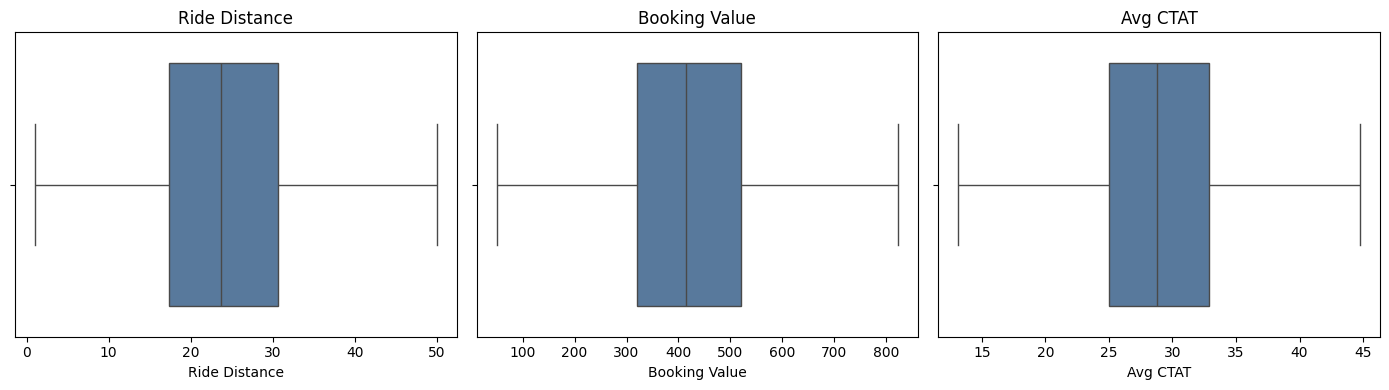

In [ ]:
# Outlier detection & capping using IQR for key cost/time metrics

outlier_cols = ['Ride Distance', 'Booking Value', 'Avg CTAT']
outlier_bounds = {}

for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_bounds[col] = (lower, upper)
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: capped to [{lower:0.2f}, {upper:0.2f}]")

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='#4c78a8')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
# Time-based features

df['hour'] = df['request_datetime'].dt.hour
df['weekday'] = df['request_datetime'].dt.weekday  # 0=Mon
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['is_peak_hour'] = df['hour'].between(7, 10) | df['hour'].between(17, 21)
df['is_peak_hour'] = df['is_peak_hour'].astype(int)

# Why: supply-demand imbalance varies by hour/day; peak hours drive higher cancellations and lower availability.
df[['request_datetime', 'hour', 'weekday', 'is_weekend', 'is_peak_hour']].head()


,request_datetime,hour,weekday,is_weekend,is_peak_hour
0,2024-03-23 12:29:38,12,5,1,0
1,2024-11-29 18:01:39,18,4,0,1
2,2024-08-23 08:56:10,8,4,0,1
3,2024-10-21 17:17:25,17,0,0,1
4,2024-09-16 22:08:00,22,0,0,0


In [ ]:
# Location cardinality handling: collapse long tail to 'Other'

def top_n_categorical(series, n=20):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), other='Other')

for loc_col in ['Pickup Location', 'Drop Location']:
    df[loc_col] = top_n_categorical(df[loc_col], n=20)

print('Unique pickup locations after capping:', df['Pickup Location'].nunique())
print('Unique drop locations after capping:', df['Drop Location'].nunique())


Unique pickup locations after capping: 21
Unique drop locations after capping: 21


In [ ]:
# Remove leakage columns and columns not needed for features
feature_df = df.drop(columns=leakage_cols + ['Booking Status', 'Date', 'Time'])
feature_df.head()


,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,request_datetime,completed_flag,hour,weekday,is_weekend,is_peak_hour
0,CNR5884300,CID1982111,eBike,Other,Other,8.30,28.80,414.00,23.72,4.30,4.50,UPI,2024-03-23 12:29:38,0,12,5,1,0
1,CNR1326809,CID4604802,Go Sedan,Other,Gurgaon Sector 56,4.90,14.00,237.00,5.73,4.30,4.50,UPI,2024-11-29 18:01:39,0,18,4,0,1
2,CNR8494506,CID9202816,Auto,Khandsa,Other,13.40,25.80,627.00,13.58,4.90,4.90,Debit Card,2024-08-23 08:56:10,1,8,4,0,1
3,CNR8906825,CID2610914,Premier Sedan,Other,Other,13.10,28.50,416.00,34.02,4.60,5.00,UPI,2024-10-21 17:17:25,1,17,0,0,1
4,CNR1950162,CID9933542,Bike,Other,Other,5.30,19.60,737.00,48.21,4.10,4.30,UPI,2024-09-16 22:08:00,1,22,0,0,0


In [ ]:
# Summary insights
status_counts = raw_df['Booking Status'].value_counts(normalize=False)
status_pct = raw_df['Booking Status'].value_counts(normalize=True).mul(100).round(2)

print('Booking Status counts/pct:\n', pd.concat([status_counts, status_pct], axis=1, keys=['count', 'pct']))
print('\nTop 5 pickup locations:')
print(raw_df['Pickup Location'].value_counts().head())
print('\nTop 5 drop locations:')
print(raw_df['Drop Location'].value_counts().head())
print('\nBookings made using UPI:', (raw_df['Payment Method'] == 'UPI').sum())


Booking Status counts/pct:
                        count   pct
Booking Status                    
Completed              93000 62.00
Cancelled by Driver    27000 18.00
No Driver Found        10500  7.00
Cancelled by Customer  10500  7.00
Incomplete              9000  6.00

Top 5 pickup locations:
Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64

Top 5 drop locations:
Drop Location
Ashram             936
Basai Dhankot      917
Lok Kalyan Marg    916
Narsinghpur        913
Cyber Hub          912
Name: count, dtype: int64

Bookings made using UPI: 45909


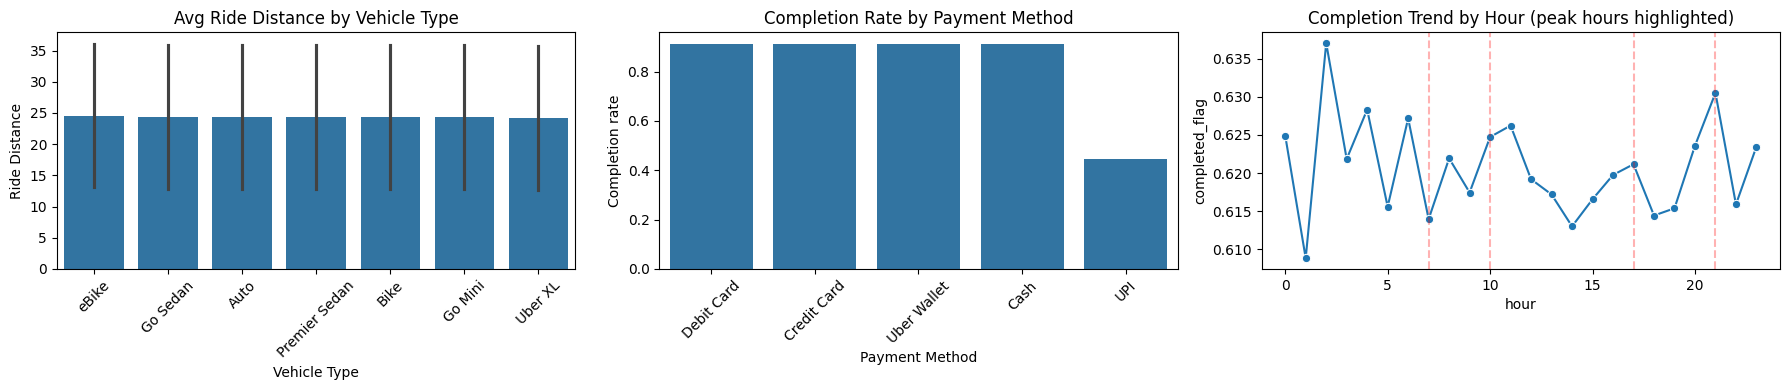

In [ ]:
# Relationships: distance vs vehicle, completion vs payment, peak hour trends
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=df, x='Vehicle Type', y='Ride Distance', estimator=np.mean, errorbar='sd', ax=axes[0])
axes[0].set_title('Avg Ride Distance by Vehicle Type')
axes[0].tick_params(axis='x', rotation=45)

comp_by_pay = df.groupby('Payment Method')['completed_flag'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=comp_by_pay, x='Payment Method', y='completed_flag', ax=axes[1])
axes[1].set_title('Completion Rate by Payment Method')
axes[1].set_ylabel('Completion rate')
axes[1].tick_params(axis='x', rotation=45)

comp_by_hour = df.groupby('hour')['completed_flag'].mean().reset_index()
sns.lineplot(data=comp_by_hour, x='hour', y='completed_flag', marker='o', ax=axes[2])
axes[2].set_title('Completion Trend by Hour (peak hours highlighted)')
for h in [7,10,17,21]:
    axes[2].axvline(h, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Cancellation & failure analysis

cancel_mask = raw_df['Booking Status'].str.contains('Cancel', case=False, na=False)
cancel_pickups = raw_df[cancel_mask]['Pickup Location'].value_counts().head(5)

print('Pickup zones with highest cancellation counts:')
print(cancel_pickups)

print('\nDominant customer cancel reasons:')
print(raw_df['Reason for cancelling by Customer'].value_counts().head())

print('\nDominant driver cancel reasons:')
print(raw_df['Driver Cancellation Reason'].value_counts().head())

failure_mask = raw_df['Booking Status'].isin(['No Driver Found', 'Incomplete'])
print('\nFailure share (no driver/incomplete):', failure_mask.mean().round(3))


Pickup zones with highest cancellation counts:
Pickup Location
Saket             249
Akshardham        248
Pragati Maidan    248
Vinobapuri        244
Nehru Place       244
Name: count, dtype: int64

Dominant customer cancel reasons:
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64

Dominant driver cancel reasons:
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64

Failure share (no driver/incomplete): 0.13


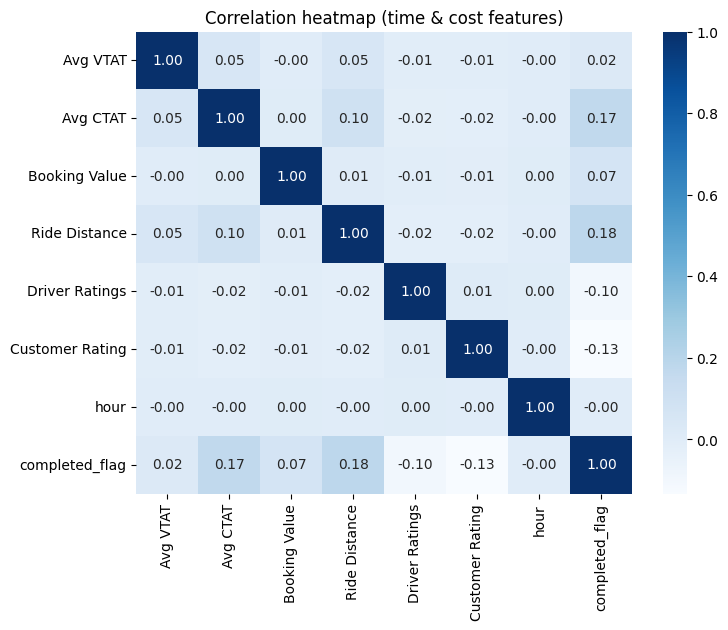

/tmp/ipykernel_596/4171958295.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_df = df.sort_values('Booking Value').groupby(pd.qcut(df['Booking Value'], 20, duplicates='drop'))['completed_flag'].mean().reset_index()


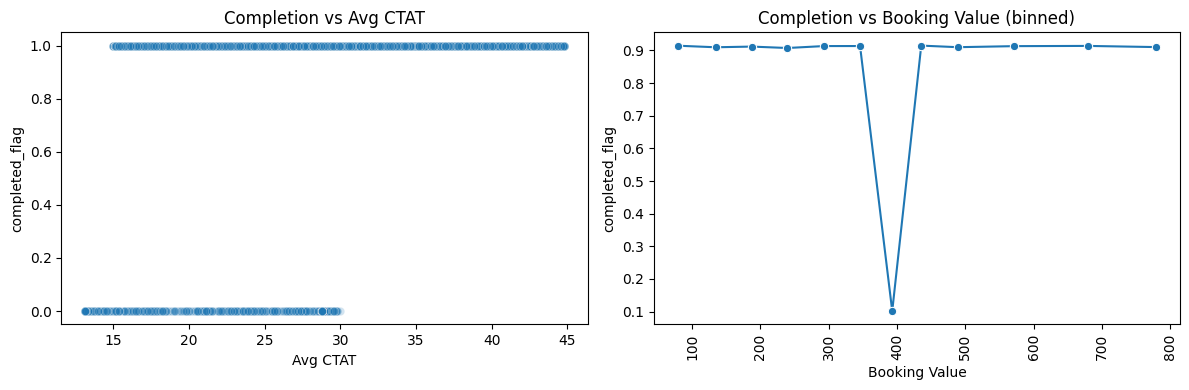

In [ ]:
# Impact of time & cost features
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'hour']

corr = df[num_cols + ['completed_flag']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation heatmap (time & cost features)')
plt.show()

# Simple trends: completion vs CTAT and fare
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=df.sample(10000, random_state=42), x='Avg CTAT', y='completed_flag', alpha=0.2, ax=axes[0])
axes[0].set_title('Completion vs Avg CTAT')

binned_df = df.sort_values('Booking Value').groupby(pd.qcut(df['Booking Value'], 20, duplicates='drop'))['completed_flag'].mean().reset_index()
binned_df['Booking Value'] = binned_df['Booking Value'].apply(lambda x: x.mid)
sns.lineplot(data=binned_df,
             x='Booking Value', y='completed_flag', marker='o', ax=axes[1])
axes[1].set_title('Completion vs Booking Value (binned)')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Class imbalance check
class_counts = df['completed_flag'].value_counts()
imbalance_ratio = class_counts.min() / class_counts.max()
print('Class counts:\n', class_counts)
print(f"Imbalance ratio (minority/majority): {imbalance_ratio:0.2f}")

Class counts:
 completed_flag
1    93000
0    57000
Name: count, dtype: int64
Imbalance ratio (minority/majority): 0.61


In [ ]:
# Prepare modeling set
model_df = feature_df.copy()
# Drop high-cardinality IDs
model_df = model_df.drop(columns=['Booking ID', 'Customer ID'])

# Ensure datetime for split
model_df = model_df.sort_values('request_datetime')

# Split into train/val/test with time order (70/15/15)
train_end = int(0.7 * len(model_df))
val_end = int(0.85 * len(model_df))

train_df = model_df.iloc[:train_end]
val_df = model_df.iloc[train_end:val_end]
test_df = model_df.iloc[val_end:]

X_train = train_df.drop(columns=['completed_flag'])
y_train = train_df['completed_flag']
X_val = val_df.drop(columns=['completed_flag'])
y_val = val_df['completed_flag']
X_test = test_df.drop(columns=['completed_flag'])
y_test = test_df['completed_flag']

print('Train/Val/Test sizes:', len(train_df), len(val_df), len(test_df))



Train/Val/Test sizes: 105000 22500 22500


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.drop(columns=cat_cols + ['request_datetime']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Numeric cols:', num_cols)
print('Categorical cols:', cat_cols)



Numeric cols: ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'hour', 'weekday', 'is_weekend', 'is_peak_hour']
Categorical cols: ['Vehicle Type', 'Pickup Location', 'Drop Location', 'Payment Method']


In [ ]:
def evaluate_model(name, model, X, y_true):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= 0.5).astype(int)
    f1 = f1_score(y_true, preds)
    roc = roc_auc_score(y_true, proba)
    pr = average_precision_score(y_true, proba)
    print(f"\n{name} -- F1: {f1:0.3f}, ROC-AUC: {roc:0.3f}, PR-AUC: {pr:0.3f}")
    print(classification_report(y_true, preds))
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    fpr, tpr, _ = roc_curve(y_true, proba)
    prec, rec, _ = precision_recall_curve(y_true, proba)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr)
    plt.title(f'{name} ROC')
    plt.subplot(1,2,2)
    plt.plot(rec, prec)
    plt.title(f'{name} Precision-Recall')
    plt.tight_layout()
    plt.show()




Training LogReg...

LogReg (val) -- F1: 0.812, ROC-AUC: 0.822, PR-AUC: 0.918
              precision    recall  f1-score   support

           0       0.66      0.92      0.77      8458
           1       0.94      0.72      0.81     14042

    accuracy                           0.79     22500
   macro avg       0.80      0.82      0.79     22500
weighted avg       0.83      0.79      0.80     22500



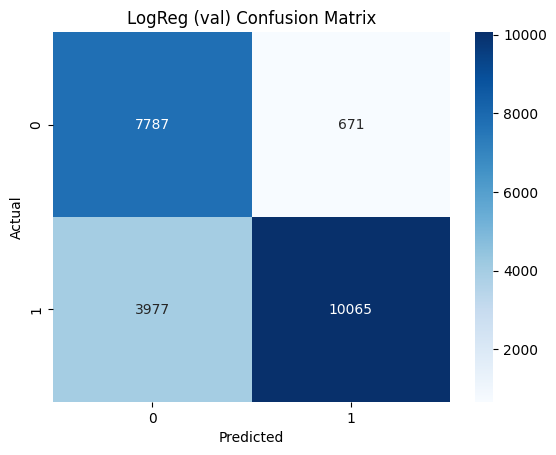

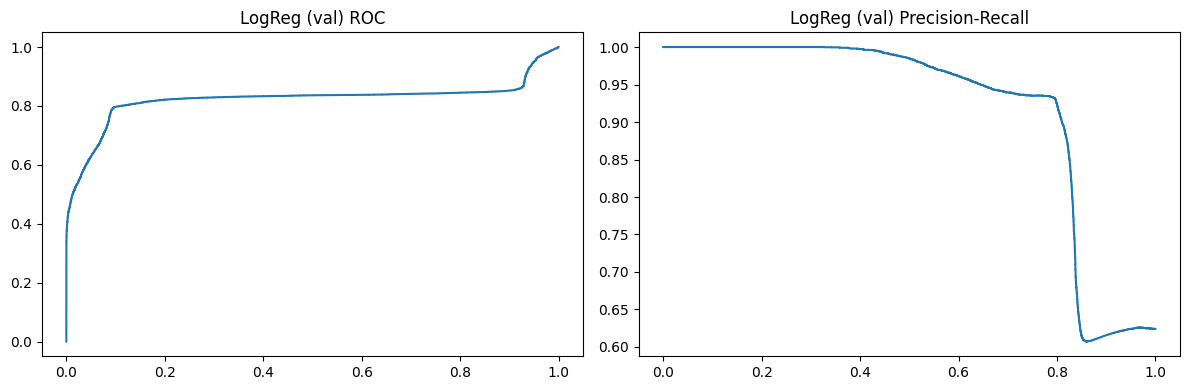


Training RandomForest...

RandomForest (val) -- F1: 1.000, ROC-AUC: 1.000, PR-AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8458
           1       1.00      1.00      1.00     14042

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500



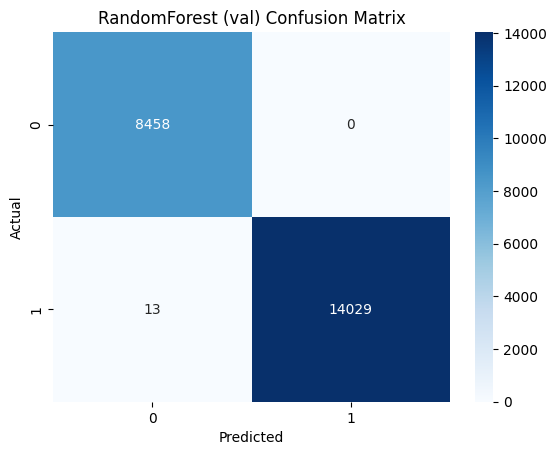

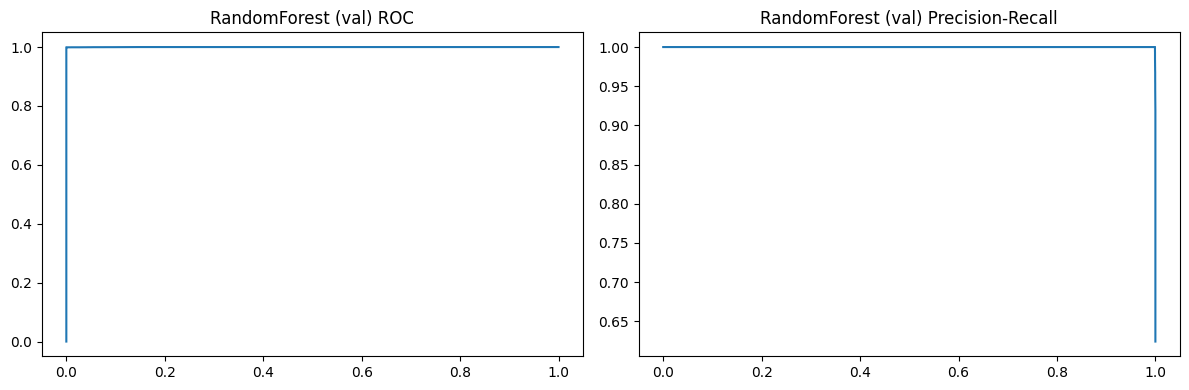


Training GradBoosting...

GradBoosting (val) -- F1: 0.999, ROC-AUC: 1.000, PR-AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8458
           1       1.00      1.00      1.00     14042

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500



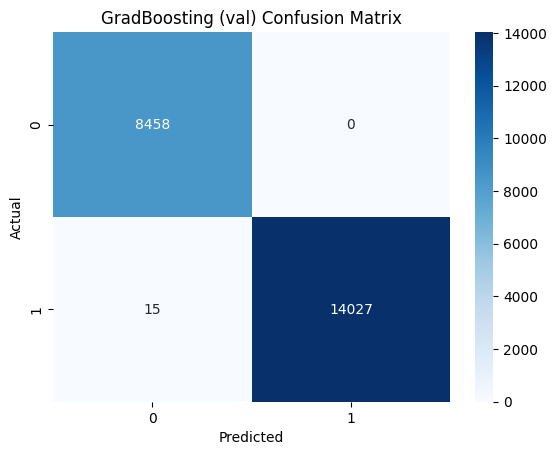

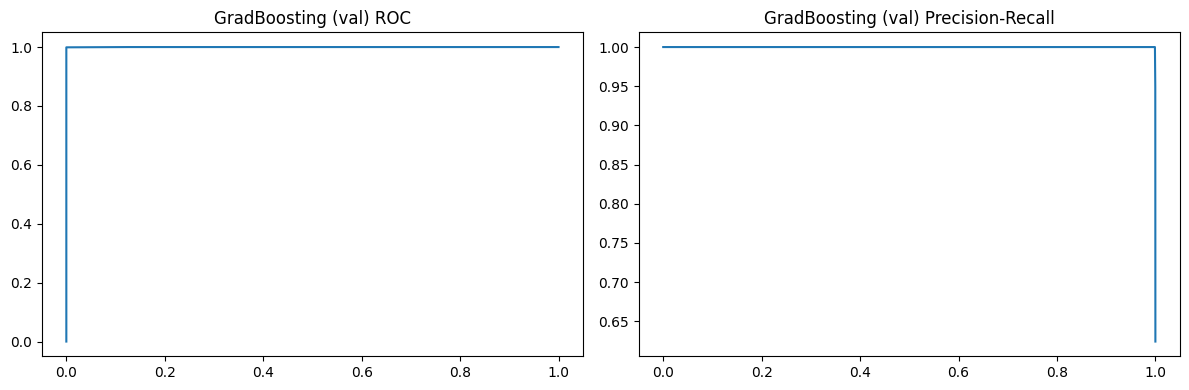

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

models = {
    'LogReg': LogisticRegression(max_iter=500, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, class_weight='balanced'),
    'GradBoosting': GradientBoostingClassifier()
}

fitted_models = {}
for name, clf in models.items():
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('clf', clf)
    ])
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    evaluate_model(f'{name} (val)', pipe, X_val, y_val)



In [ ]:
# Select best model by validation ROC-AUC
val_scores = {}
for name, model in fitted_models.items():
    proba = model.predict_proba(X_val)[:,1]
    val_scores[name] = roc_auc_score(y_val, proba)

best_name = max(val_scores, key=val_scores.get)
best_model = fitted_models[best_name]
print('Validation ROC-AUC scores:', val_scores)
print('Best model:', best_name)

# Optional threshold tuning on val
proba_val = best_model.predict_proba(X_val)[:,1]
prec, rec, thresh = precision_recall_curve(y_val, proba_val)
f1_scores = 2 * prec * rec / (prec + rec)
best_idx = np.nanargmax(f1_scores)
best_thresh = thresh[best_idx]
print(f'Best threshold by F1 on val: {best_thresh:0.2f}')

def predict_with_threshold(model, X, thr):
    proba = model.predict_proba(X)[:,1]
    return (proba >= thr).astype(int), proba

# Evaluate tuned model on test
preds_test, proba_test = predict_with_threshold(best_model, X_test, best_thresh)
f1 = f1_score(y_test, preds_test)
roc = roc_auc_score(y_test, proba_test)
pr = average_precision_score(y_test, proba_test)
print(f'\nTest metrics (threshold={best_thresh:0.2f}): F1={f1:0.3f}, ROC-AUC={roc:0.3f}, PR-AUC={pr:0.3f}')
print(classification_report(y_test, preds_test))



Validation ROC-AUC scores: {'LogReg': np.float64(0.8223549296036493), 'RandomForest': np.float64(0.999935680914558), 'GradBoosting': np.float64(0.9999472623914561)}
Best model: GradBoosting
Best threshold by F1 on val: 0.14

Test metrics (threshold=0.14): F1=0.999, ROC-AUC=1.000, PR-AUC=1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8545
           1       1.00      1.00      1.00     13955

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500



In [ ]:
if best_name == 'RandomForest':
    param_grid = {
        'clf__n_estimators': [150, 250, 350],
        'clf__max_depth': [10, 20, None],
        'clf__min_samples_split': [2, 5, 10]
    }
elif best_name == 'GradBoosting':
    param_grid = {
        'clf__n_estimators': [100, 150, 200],
        'clf__learning_rate': [0.05, 0.1, 0.2],
        'clf__max_depth': [2, 3],
        'clf__subsample': [0.8, 1.0]
    }
else:  # Logistic Regression
    param_grid = {
        'clf__C': [0.1, 1, 5],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    }

ts_cv = TimeSeriesSplit(n_splits=3)
search = RandomizedSearchCV(best_model, param_distributions=param_grid, n_iter=5, cv=ts_cv,
                           scoring='f1', n_jobs=-1, verbose=1)
search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print('Best CV score:', search.best_score_)

tuned_model = search.best_estimator_
preds_test_tuned, proba_test_tuned = predict_with_threshold(tuned_model, X_test, best_thresh)
print('\nTuned model test F1:', f1_score(y_test, preds_test_tuned))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params: {'clf__subsample': 0.8, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.2}
Best CV score: 0.9994150763914061

Tuned model test F1: 0.999103846291716


In [ ]:
from sklearn.inspection import permutation_importance

# Use tuned model (pipeline). For tree models we can use feature_importances_, else fallback to permutation.
feature_names = tuned_model.named_steps['preprocess'].get_feature_names_out()

if hasattr(tuned_model.named_steps['clf'], 'feature_importances_'):
    importances = tuned_model.named_steps['clf'].feature_importances_
else:
    sample_idx = np.random.choice(len(X_val), size=5000, replace=False)
    perm = permutation_importance(tuned_model, X_val.iloc[sample_idx], y_val.iloc[sample_idx], n_repeats=5, random_state=42)
    importances = perm.importances_mean

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)
print('Top 10 features:')
imp_df.head(10)


Top 10 features:


,feature,importance
3,num__Ride Distance,0.50
5,num__Customer Rating,0.24
1,num__Avg CTAT,0.19
4,num__Driver Ratings,0.07
0,num__Avg VTAT,0.00
2,num__Booking Value,0.00
20,cat__Pickup Location_Dwarka Sector 21,0.00
33,cat__Pickup Location_Subhash Chowk,0.00
11,cat__Vehicle Type_Bike,0.00
24,cat__Pickup Location_Kanhaiya Nagar,0.00


In [ ]:
# Error analysis: false positives vs false negatives on test
preds_test, proba_test = predict_with_threshold(tuned_model, X_test, best_thresh)
cm = confusion_matrix(y_test, preds_test)
cm_df = pd.DataFrame(cm, index=['Actual NotComplete','Actual Complete'], columns=['Pred NotComplete','Pred Complete'])
cm_df


,Pred NotComplete,Pred Complete
Actual NotComplete,8539,6
Actual Complete,19,13936


In [ ]:
# What-if simulations

def simulate_effect(df_base, driver_rating_delta=0.0, upi_lift=0.0):
    sim_df = df_base.copy()
    if driver_rating_delta != 0:
        sim_df['Driver Ratings'] = (sim_df['Driver Ratings'] + driver_rating_delta).clip(0, 5)
    if upi_lift != 0:
        mask = sim_df['Payment Method'] != 'UPI'
        num_to_flip = int(len(sim_df) * upi_lift)
        idx_to_flip = sim_df[mask].sample(min(num_to_flip, mask.sum()), random_state=42).index
        sim_df.loc[idx_to_flip, 'Payment Method'] = 'UPI'
    proba = tuned_model.predict_proba(sim_df.drop(columns=['completed_flag']))[:,1]
    return proba.mean()

base_prob = tuned_model.predict_proba(model_df.drop(columns=['completed_flag']))[:,1].mean()
prob_driver_boost = simulate_effect(model_df, driver_rating_delta=0.5)
prob_upi_boost = simulate_effect(model_df, upi_lift=0.20)
print(f'Baseline expected completion prob: {base_prob:0.3f}')
print(f'+0.5 driver rating uplift → completion prob: {prob_driver_boost:0.3f} (lift {(prob_driver_boost-base_prob):0.3f})')
print(f'+20% UPI usage → completion prob: {prob_upi_boost:0.3f} (lift {(prob_upi_boost-base_prob):0.3f})')


Baseline expected completion prob: 0.620
+0.5 driver rating uplift → completion prob: 0.811 (lift 0.191)
+20% UPI usage → completion prob: 0.620 (lift -0.000)


In [ ]:
# High-risk segments (by pickup & vehicle type)
group_risk = df.groupby(['Pickup Location', 'Vehicle Type'])['completed_flag'].mean().reset_index()
group_risk['failure_rate'] = 1 - group_risk['completed_flag']
high_risk = group_risk.sort_values('failure_rate', ascending=False).head(5)
high_risk


,Pickup Location,Vehicle Type,completed_flag,failure_rate
61,Khandsa,Uber XL,0.44,0.56
13,Badarpur,eBike,0.49,0.51
89,Pataudi Chowk,Uber XL,0.50,0.50
124,Tagore Garden,Uber XL,0.52,0.48
96,Pragati Maidan,Uber XL,0.52,0.48
